# EDA de référence NutriScope (TP 10)

Données : Open Food Facts, © Open Food Facts contributors — ODbL.

Le notebook se rejoue de haut en bas (`jupyter nbconvert --to notebook --execute --inplace notebooks/eda_reference.ipynb`). Les calculs sont dans `src/eda_lib.py` et testés dans `tests/test_eda_lib.py` ; ici on trace et on interprète. Chaque section suit le même gabarit : question, méthode, résultat, trois lignes, décision.

In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# racine du dépôt, que le notebook soit lancé depuis la racine ou depuis notebooks/
RACINE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "eda_lib.py").exists())
sys.path.insert(0, str(RACINE))

from src import eda_lib
from src.cleaning import lire_brut

rng = np.random.default_rng(eda_lib.GRAINE)
FIGURES = RACINE / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# une seule couleur pour les mesures, du gris pour le contexte, une échelle bleu -> rouge pour les grades
BLEU, ORANGE, GRIS, ENCRE, ENCRE_2 = "#2a78d6", "#eb6834", "#c3c2b7", "#0b0b0b", "#52514e"
COULEURS_GRADES = {"a": "#184f95", "b": "#6da7ec", "c": "#d6d5cd", "d": "#e66767", "e": "#a81f1f"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRIS,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": ENCRE_2, "xtick.color": ENCRE_2, "ytick.color": ENCRE_2,
    "grid.color": "#e1e0d9", "font.size": 9,
})


def figure(fig, nom):
    """Sauvegarde la figure dans notebooks/figures/ puis affiche le PNG."""
    chemin = FIGURES / f"{nom}.png"
    fig.savefig(chemin, dpi=120, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(chemin)))

## 0. Données

**Cas dégradé.** Le TP 9 n'est pas terminé : il manque la déduplication, le traitement des catégories et la stratégie de manquants. On applique donc le nettoyage minimal du module 3.3 (`eda_lib.nettoyage_minimal`) :

- doublons de codes-barres : première occurrence gardée ;
- nutriment hors 0–100 g/100 g : ligne écartée ;
- énergie hors 0–900 kcal/100 g : ligne écartée ;
- les manquants sont conservés.

Les produits sans rayon ou de rayon `unknown` restent dans le périmètre mais sont écartés des comparaisons par rayon (`eda_lib.rayons_connus`).

Ce nettoyage sera remplacé par `src.cleaning.nettoyer` quand le TP 9 sera livré : seule la cellule ci-dessous change.

In [2]:
brut = lire_brut(RACINE / "data" / "echantillon_france.csv")
perimetre = eda_lib.nettoyage_minimal(brut)      # à remplacer par nettoyer(brut) (TP 9)
par_rayon = eda_lib.rayons_connus(perimetre)

inconnus = len(perimetre) - len(par_rayon)
print(f"brut          : {len(brut):>6} produits")
print(f"périmètre     : {len(perimetre):>6} produits")
print(f"rayon connu   : {len(par_rayon):>6} produits")
print(f"rayon inconnu : {inconnus:>6} produits ({inconnus / len(perimetre):.1%} du périmètre)")

brut          :   8689 produits
périmètre     :   8400 produits
rayon connu   :   6674 produits
rayon inconnu :   1726 produits (20.5% du périmètre)


## 1. Distributions des nutriments clés par rayon

### Question

Que mange-t-on réellement dans le périmètre ? Les rayons se ressemblent-ils, ou chacun a-t-il son profil ?

### Méthode

- `resume_univarie` sur sucres, sel et énergie : on regarde la forme avant de comparer.
- `profil_par_rayon` : médiane et quartiles par rayon, les groupes de moins de 30 valeurs sont écartés.
- `croisement_rayon_grade` en % par ligne et V de Cramér, sur les grades a–e uniquement.

Tout est calculé sur les 6 674 produits de rayon connu.

### Résultat

In [3]:
NUTS = ["sugars_100g", "salt_100g", "energy-kcal_100g"]
LIBELLES = {"sugars_100g": "Sucres (g/100 g)", "salt_100g": "Sel (g/100 g)", "energy-kcal_100g": "Énergie (kcal/100 g)"}

resume = pd.DataFrame({c: eda_lib.resume_univarie(par_rayon[c]) for c in NUTS}).T
resume.round(2)

,n,manquants,moyenne,mediane,ecart_type,IQR,MAD,CV,asymetrie,aplatissement,p05,Q1,Q3,p95,min,max
sugars_100g,5546.0,1128.0,12.94,3.0,19.79,15.60,3.00,1.53,1.89,2.94,0.0,0.60,16.2,57.50,0.0,100.0
salt_100g,5418.0,1256.0,1.07,0.5,2.37,1.25,0.49,2.23,11.13,240.78,0.0,0.05,1.3,3.67,0.0,77.5
energy-kcal_100g,5599.0,1075.0,275.07,254.0,192.81,286.00,143.00,0.70,0.71,0.25,23.0,111.00,397.0,597.00,0.0,900.0


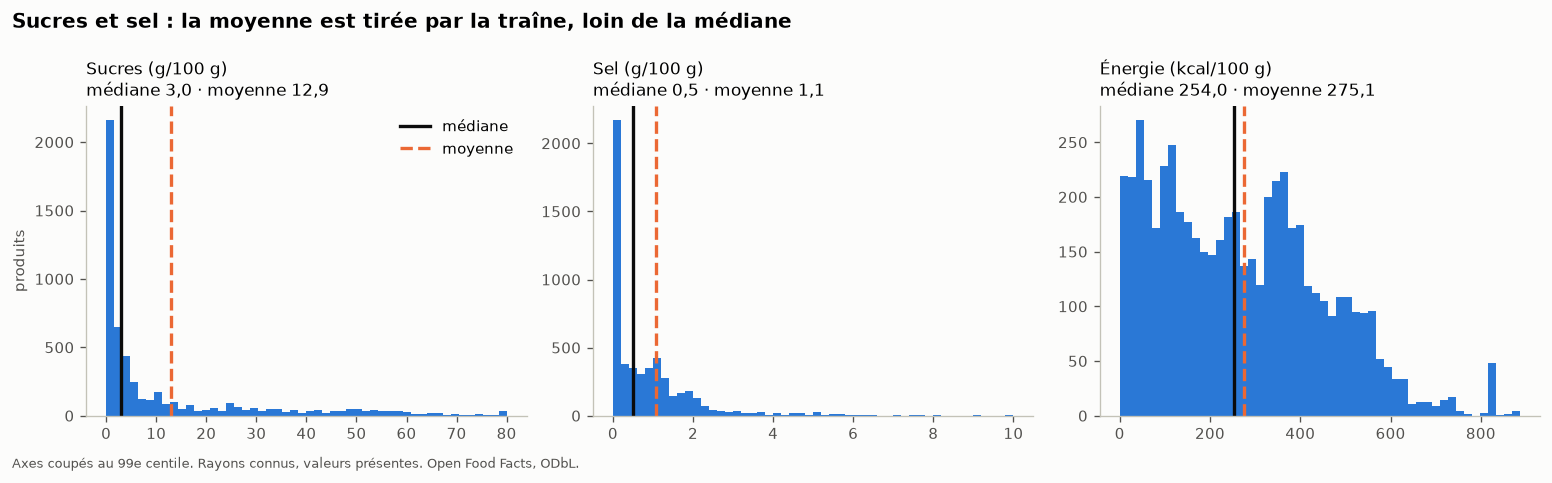

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, c in zip(axes, NUTS):
    x = par_rayon[c].dropna()
    ax.hist(x[x <= x.quantile(0.99)], bins=50, color=BLEU)
    ax.axvline(resume.loc[c, "mediane"], color=ENCRE, linewidth=2, label="médiane")
    ax.axvline(resume.loc[c, "moyenne"], color=ORANGE, linewidth=2, linestyle="--", label="moyenne")
    titre = f"{LIBELLES[c]}\nmédiane {resume.loc[c, 'mediane']:.1f} · moyenne {resume.loc[c, 'moyenne']:.1f}"
    ax.set_title(titre.replace(".", ","), fontweight="normal", fontsize=10)
axes[0].set_ylabel("produits")
axes[0].legend(frameon=False)
fig.suptitle("Sucres et sel : la moyenne est tirée par la traîne, loin de la médiane",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.text(0.01, -0.02, "Axes coupés au 99e centile. Rayons connus, valeurs présentes. Open Food Facts, ODbL.",
         color=ENCRE_2, fontsize=8)
fig.tight_layout()
figure(fig, "1-histogrammes-nutriments")

**Trois lignes.**

1. Sucres et sel sont très asymétriques : la moyenne vaut quatre fois la médiane pour les sucres (12,9 g contre 3,0 g) et deux fois pour le sel (1,07 g contre 0,5 g).
2. L'énergie est la seule des trois à peu près symétrique (médiane 254 kcal, moyenne 275 kcal).
3. Entre 16 % et 19 % des valeurs manquent selon le nutriment, et le sel garde un maximum à 77,5 g/100 g : à examiner en section 4.

In [5]:
profil = eda_lib.profil_par_rayon(par_rayon, NUTS)
ecartes = eda_lib.rayons_ecartes(par_rayon, NUTS)
print(f"groupes écartés (moins de 30 valeurs) : {len(ecartes)}")
profil.loc["sugars_100g"].sort_values("mediane", ascending=False).round(1)

groupes écartés (moins de 30 valeurs) : 0


,n,Q1,mediane,Q3,moyenne
rayon,,,,,
Sugary snacks,1185,24.0,38.0,53.0,39.4
Beverages,452,0.1,6.1,10.5,10.1
Baby foods,50,2.3,5.6,10.5,10.3
Fruits and vegetables,373,1.2,4.6,15.0,15.3
Milk and dairy products,666,0.5,3.7,11.8,7.2
Cereals and potatoes,606,1.0,2.7,4.5,4.9
Salty snacks,332,1.0,2.6,4.5,3.6
Composite foods,457,1.1,2.2,3.4,3.0
Fat and sauces,442,0.0,1.5,6.0,6.4


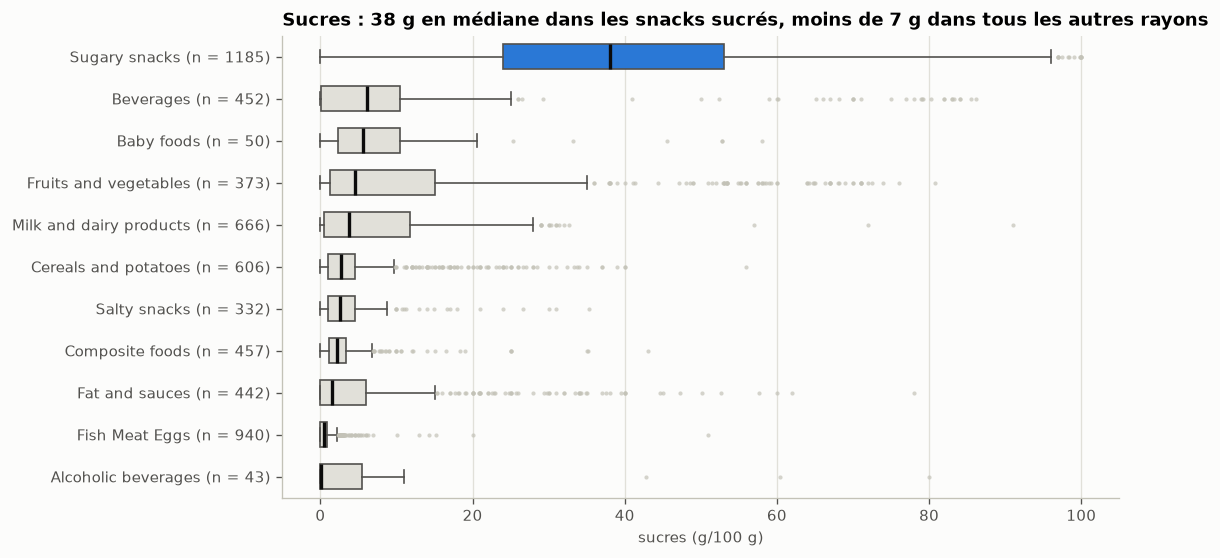

In [6]:
sucres = profil.loc["sugars_100g"].sort_values("mediane")
series = [par_rayon.loc[par_rayon[eda_lib.RAYON] == r, "sugars_100g"].dropna() for r in sucres.index]

fig, ax = plt.subplots(figsize=(9, 5))
boites = ax.boxplot(series, orientation="horizontal", patch_artist=True, widths=0.6,
                    tick_labels=[f"{r} (n = {int(n)})" for r, n in sucres["n"].items()],
                    medianprops={"color": ENCRE, "linewidth": 2},
                    whiskerprops={"color": ENCRE_2}, capprops={"color": ENCRE_2},
                    flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": GRIS,
                                "markeredgecolor": "none", "alpha": 0.7})
for boite, rayon in zip(boites["boxes"], sucres.index):
    boite.set(facecolor=BLEU if rayon == "Sugary snacks" else "#e1e0d9", edgecolor=ENCRE_2)
ax.set_xlabel("sucres (g/100 g)")
ax.grid(axis="x")
ax.set_title("Sucres : 38 g en médiane dans les snacks sucrés, moins de 7 g dans tous les autres rayons")
figure(fig, "1-boites-sucres-par-rayon")

**Trois lignes.**

1. Les snacks sucrés sont à part : 38 g de sucres en médiane (quartiles 24 et 53 g), six fois la médiane du rayon suivant, les boissons (6,1 g).
2. Dans les autres rayons la boîte est basse mais les extrêmes montent haut : en fruits et légumes la moyenne (15,3 g) vaut trois fois la médiane (4,6 g).
3. Aucun groupe n'est écarté par le seuil de 30, mais les boissons alcoolisées (n = 43) et les aliments pour bébés (n = 50) restent des petits rayons : à commenter avec prudence.

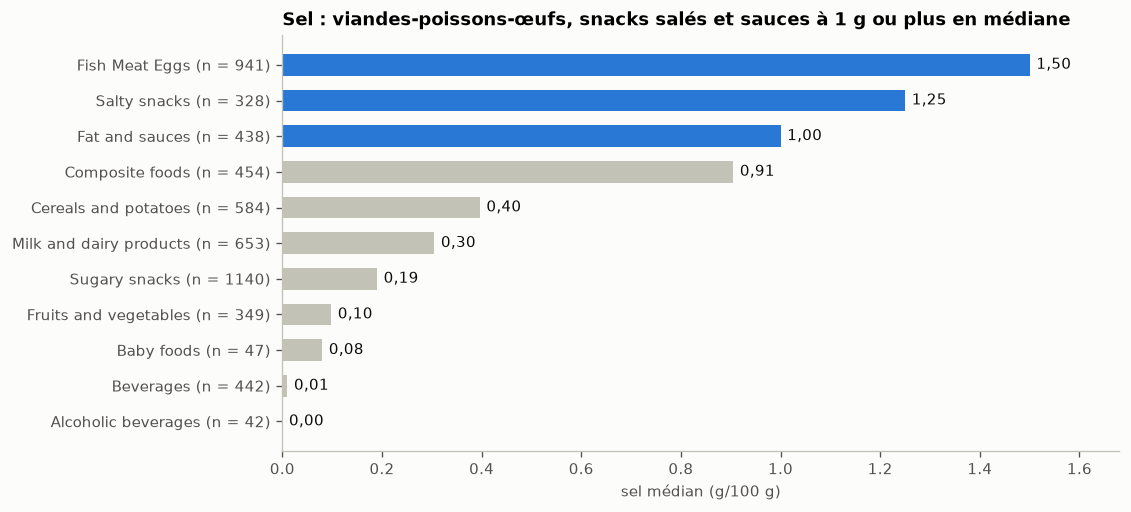

In [7]:
sel = profil.loc["salt_100g"].sort_values("mediane")

fig, ax = plt.subplots(figsize=(9, 4.5))
barres = ax.barh([f"{r} (n = {int(n)})" for r, n in sel["n"].items()], sel["mediane"], height=0.6,
                 color=[BLEU if m >= 1 else GRIS for m in sel["mediane"]])
ax.bar_label(barres, labels=[f"{m:.2f}".replace(".", ",") for m in sel["mediane"]], padding=4, color=ENCRE)
ax.set_xlabel("sel médian (g/100 g)")
ax.set_xlim(0, sel["mediane"].max() * 1.12)
ax.set_title("Sel : viandes-poissons-œufs, snacks salés et sauces à 1 g ou plus en médiane")
figure(fig, "1-sel-median-par-rayon")

**Trois lignes.**

1. Trois rayons atteignent 1 g de sel en médiane : viandes-poissons-œufs (1,5 g), snacks salés (1,25 g), matières grasses et sauces (1,0 g).
2. Les boissons sont à 0,01 g : le sel n'y dit presque rien, les sucres y disent tout.
3. Le classement par sel n'est pas celui par sucres : les snacks sucrés, premiers en sucres, sont à 0,19 g de sel.

In [8]:
table = eda_lib.croisement_rayon_grade(par_rayon)
parts = eda_lib.parts_par_ligne(table)
v = eda_lib.v_cramer(table)
print(f"{int(table.to_numpy().sum())} produits notés a–e dans {len(table)} rayons ; V de Cramér = {v:.2f}")
parts.round(1).assign(n=table.sum(axis=1))

5149 produits notés a–e dans 9 rayons ; V de Cramér = 0.34


nutriscore_grade,a,b,c,d,e,n
pnns_groups_1,,,,,,
Beverages,6.9,24.4,27.6,17.2,23.9,377
Cereals and potatoes,33.3,19.8,26.3,16.8,3.9,571
Composite foods,8.4,15.9,48.3,23.7,3.7,464
Fat and sauces,6.4,20.6,20.4,16.0,36.6,407
Fish Meat Eggs,20.0,9.2,13.3,27.4,30.2,928
Fruits and vegetables,50.3,14.2,16.3,12.5,6.7,344
Milk and dairy products,5.2,7.2,30.6,45.8,11.2,635
Salty snacks,9.8,9.8,20.0,29.5,30.8,325
Sugary snacks,0.9,0.8,5.6,26.6,66.1,1098


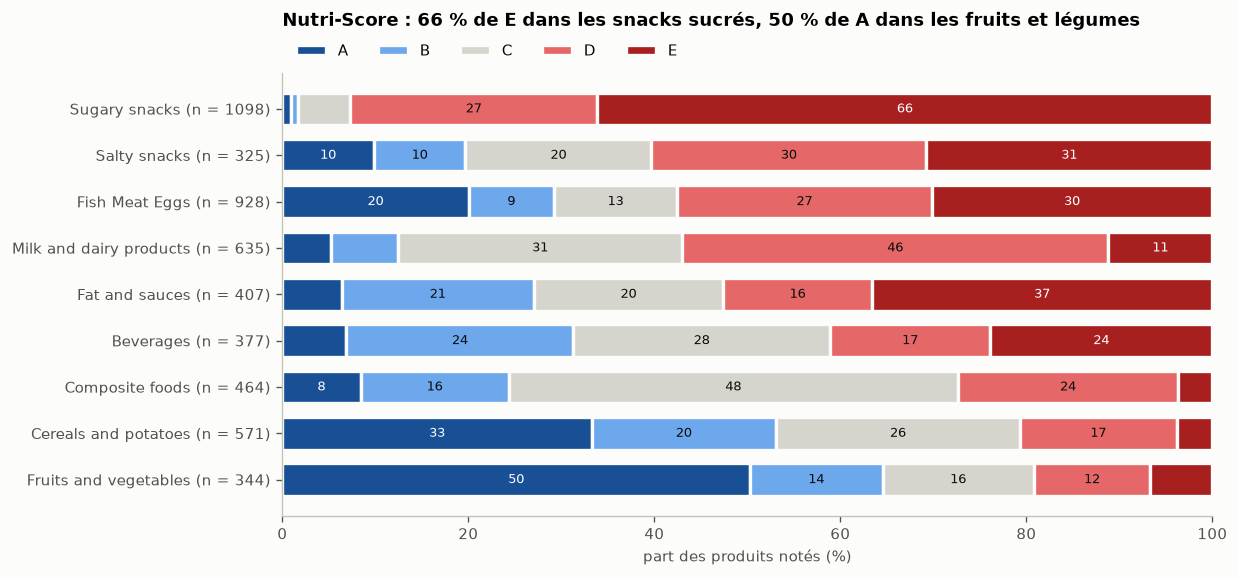

In [9]:
ordre = (parts["d"] + parts["e"]).sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.8))
gauche = np.zeros(len(ordre))
etiquettes = [f"{r} (n = {table.loc[r].sum()})" for r in ordre]
for grade in eda_lib.GRADES:
    valeurs = parts.loc[ordre, grade].to_numpy()
    barres = ax.barh(etiquettes, valeurs, left=gauche, height=0.7, label=grade.upper(),
                     color=COULEURS_GRADES[grade], edgecolor="#fcfcfb", linewidth=2)
    ax.bar_label(barres, labels=[f"{x:.0f}" if x >= 8 else "" for x in valeurs], label_type="center",
                 color="white" if grade in ("a", "e") else ENCRE, fontsize=8)
    gauche += valeurs
ax.set_xlim(0, 100)
ax.set_xlabel("part des produits notés (%)")
ax.legend(ncol=5, frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0))
ax.set_title("Nutri-Score : 66 % de E dans les snacks sucrés, 50 % de A dans les fruits et légumes", pad=28)
figure(fig, "1-grades-par-rayon")

**Trois lignes.**

1. La répartition des grades change du tout au tout d'un rayon à l'autre : 66 % de E dans les snacks sucrés (93 % de D ou E), 50 % de A dans les fruits et légumes.
2. Le V de Cramér vaut 0,34 sur 5 149 produits notés : le rayon et le grade sont liés, sans que le rayon suffise à donner la note.
3. 23 % des produits de rayon connu n'ont pas de grade a–e (`unknown`, `not-applicable`) ; les boissons alcoolisées (2 produits notés) et les aliments pour bébés (aucun) sortent de ce croisement.

### Décision

1. **TP 14** : le modèle recevra le rayon (`pnns_groups_1`) comme variable.
2. **Suite de l'EDA** : médianes et quartiles partout ; la moyenne n'est citée qu'avec un commentaire sur les extrêmes. Pour les sucres et le sel, une transformation `log1p` sera à tester au TP 14.
3. **TP 11** : le message d'ouverture est trouvé — « la moitié des snacks sucrés dépasse 38 g de sucres pour 100 g, six fois plus que le rayon suivant ».

## 2. Complétude et qualité par rayon et par marque

### Question

Où les données sont-elles fiables, où faudra-t-il être prudent ?

### Méthode

- `completude_par_groupe` : pour chaque rayon puis chaque marque, part des produits où chacun des sept nutriments clés est renseigné, part de fiches complètes (les sept à la fois) et part de produits avec un score. Marques d'au moins 20 produits.
- `incoherences_metier` : cinq drapeaux par produit. On compte, on ne corrige pas.

Cette section porte sur tout le périmètre (8 400 produits) : le rayon `unknown` est montré à part, pour le signaler, pas pour le comparer.

### Résultat

In [10]:
CLES = eda_lib.NUTRIMENTS_CLES
completude_rayon = eda_lib.completude_par_groupe(perimetre, eda_lib.RAYON, CLES)
connus = par_rayon[CLES].notna().all(axis=1).mean() * 100
print(f"fiches complètes sur les rayons connus : {connus:.1f} %")
completude_rayon.round(1)

fiches complètes sur les rayons connus : 79.5 %


,n,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,fiches_completes,score_present
pnns_groups_1,,,,,,,,,,
Baby foods,50,100.0,98.0,100.0,98.0,100.0,100.0,94.0,92.0,0.0
Composite foods,502,91.0,90.6,91.0,90.6,91.0,91.0,90.4,90.0,92.4
Fat and sauces,496,89.5,89.3,89.1,89.3,89.1,89.3,88.3,86.5,82.1
Salty snacks,375,89.1,88.8,88.8,88.5,88.5,89.1,87.5,85.9,86.7
Cereals and potatoes,678,90.3,89.8,88.9,90.0,89.4,90.3,86.1,85.0,84.2
Milk and dairy products,775,86.8,86.6,86.1,86.6,85.9,86.6,84.3,83.4,81.9
Sugary snacks,1388,85.5,85.2,85.4,85.2,85.4,85.2,82.1,81.1,79.1
Fish Meat Eggs,1175,81.1,81.1,80.3,80.8,80.0,81.1,80.1,78.6,79.0
Beverages,547,85.6,84.5,81.5,85.4,82.6,84.8,80.8,76.1,68.9


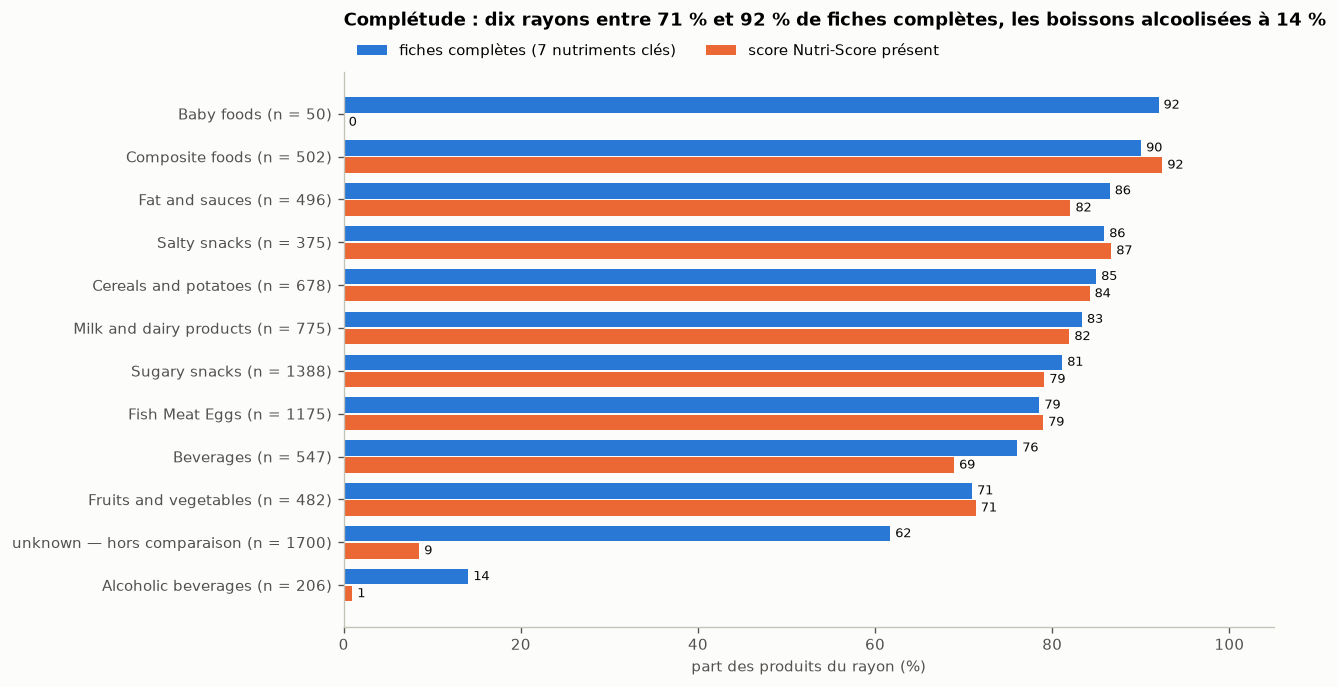

In [11]:
t = completude_rayon.sort_values("fiches_completes")
y = np.arange(len(t))
noms = [f"{'unknown — hors comparaison' if r == 'unknown' else r} (n = {n})" for r, n in t["n"].items()]

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.barh(y + 0.2, t["fiches_completes"], height=0.36, color=BLEU, label="fiches complètes (7 nutriments clés)")
b2 = ax.barh(y - 0.2, t["score_present"], height=0.36, color=ORANGE, label="score Nutri-Score présent")
ax.bar_label(b1, fmt="%.0f", padding=3, color=ENCRE, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=3, color=ENCRE, fontsize=8)
ax.set_yticks(y, noms)
ax.set_xlim(0, 105)
ax.set_xlabel("part des produits du rayon (%)")
ax.legend(ncol=2, frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0))
ax.set_title("Complétude : dix rayons entre 71 % et 92 % de fiches complètes, les boissons alcoolisées à 14 %", pad=28)
figure(fig, "2-completude-par-rayon")

**Trois lignes.**

1. Dix rayons ont entre 71 % et 92 % de fiches complètes ; sur l'ensemble des rayons connus, 79,5 %.
2. Deux rayons sont à part : les boissons alcoolisées (14 % de fiches complètes, 1 % de scores) et les aliments pour bébés (92 % de fiches complètes mais aucun score, le Nutri-Score ne s'y applique pas).
3. Le rayon `unknown` (1 700 produits, 20 % du périmètre) a 62 % de fiches complètes mais seulement 8,5 % de scores.

In [12]:
completude_marque = eda_lib.completude_par_groupe(perimetre, "brands", CLES, min_n=20)
marques = perimetre["brands"]
print(f"marque renseignée : {marques.notna().mean():.1%} des produits ; {marques.nunique()} graphies distinctes")
print(f"marques d'au moins 20 produits : {len(completude_marque)}, soit {int(completude_marque['n'].sum())} produits")
completude_marque.round(1)

marque renseignée : 69.6% des produits ; 3485 graphies distinctes
marques d'au moins 20 produits : 15, soit 823 produits


,n,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,fiches_completes,score_present
brands,,,,,,,,,,
Thiriet,31,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,96.8
Picard,38,100.0,100.0,100.0,100.0,100.0,100.0,97.4,97.4,94.7
Le Gaulois,35,97.1,97.1,97.1,97.1,97.1,97.1,97.1,97.1,94.3
Nestlé,28,96.4,96.4,96.4,96.4,96.4,96.4,96.4,96.4,67.9
Casino,50,96.0,96.0,96.0,96.0,96.0,96.0,96.0,96.0,92.0
Leader Price,60,95.0,95.0,95.0,95.0,95.0,95.0,91.7,91.7,80.0
Franprix,22,90.9,90.9,90.9,90.9,90.9,90.9,86.4,86.4,86.4
Monoprix,42,90.5,90.5,88.1,90.5,90.5,90.5,88.1,85.7,76.2
U,114,86.0,86.8,86.8,86.8,86.8,86.0,86.0,85.1,78.9


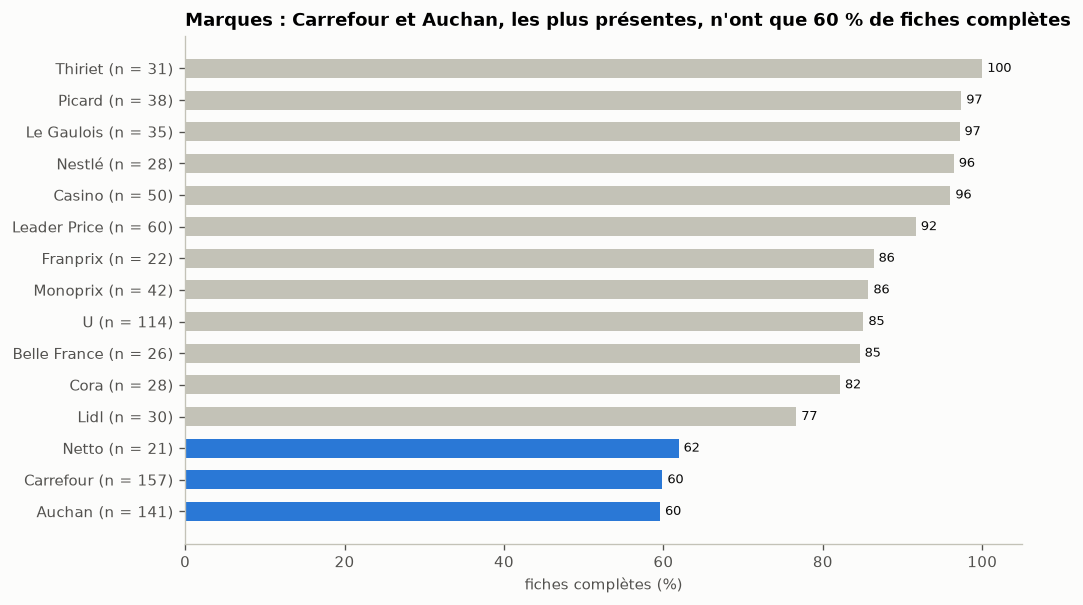

In [13]:
t = completude_marque.sort_values("fiches_completes")

fig, ax = plt.subplots(figsize=(9, 5.5))
barres = ax.barh([f"{m} (n = {n})" for m, n in t["n"].items()], t["fiches_completes"], height=0.6,
                 color=[BLEU if x < 70 else GRIS for x in t["fiches_completes"]])
ax.bar_label(barres, fmt="%.0f", padding=3, color=ENCRE, fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel("fiches complètes (%)")
ax.set_title("Marques : Carrefour et Auchan, les plus présentes, n'ont que 60 % de fiches complètes")
figure(fig, "2-completude-par-marque")

**Trois lignes.**

1. Seules 15 marques ont au moins 20 produits ; elles couvrent 823 produits sur 8 400. La marque manque pour 30 % des produits.
2. Thiriet, Picard, Le Gaulois, Nestlé et Casino dépassent 96 % de fiches complètes ; Carrefour (n = 157) et Auchan (n = 141), les deux marques les plus présentes, sont à 60 %.
3. Les graphies ne sont pas regroupées (« Carrefour », « Carrefour BIO », « carrefour »… 3 485 graphies en tout) : les effectifs par marque sont des minimums.

In [14]:
drapeaux = eda_lib.incoherences_metier(perimetre)
print(f"au moins une incohérence : {int(drapeaux.any(axis=1).sum())} produits sur {len(perimetre)}"
      f" ({drapeaux.any(axis=1).mean():.1%})")
drapeaux.sum().rename("produits").to_frame()

au moins une incohérence : 465 produits sur 8400 (5.5%)


,produits
sucres_sup_glucides,122
satures_sup_lipides,120
sel_different_sodium,132
energie_ecart_449,119
energie_nulle_macros,23


6731 produits avec énergie et trois macronutriments ; corrélation 0.97 ; écart médian 1.7 kcal


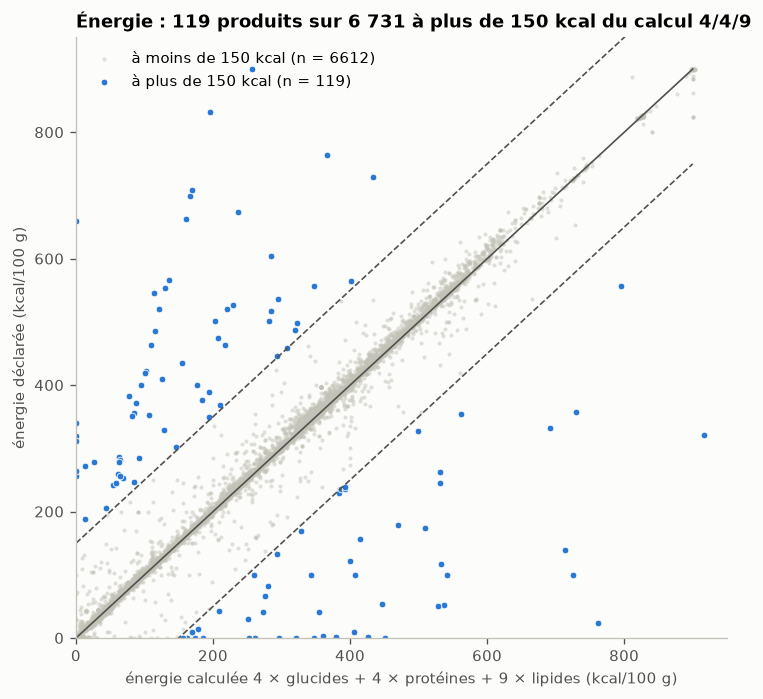

In [15]:
energie = pd.DataFrame({"declaree": perimetre["energy-kcal_100g"],
                        "calculee": eda_lib.energie_calculee(perimetre),
                        "ecart": drapeaux["energie_ecart_449"]}).dropna()
ok, hors = energie[~energie["ecart"]], energie[energie["ecart"]]
print(f"{len(energie)} produits avec énergie et trois macronutriments ; corrélation {energie['declaree'].corr(energie['calculee']):.2f}"
      f" ; écart médian {(energie['declaree'] - energie['calculee']).median():.1f} kcal")

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(ok["calculee"], ok["declaree"], s=6, color=GRIS, alpha=0.5, linewidths=0,
           label=f"à moins de 150 kcal (n = {len(ok)})")
ax.scatter(hors["calculee"], hors["declaree"], s=16, color=BLEU, edgecolors="#fcfcfb", linewidths=0.5,
           label=f"à plus de 150 kcal (n = {len(hors)})")
ax.plot([0, 900], [0, 900], color=ENCRE_2, linewidth=1)
for decalage in (-150, 150):
    ax.plot([0, 900], [decalage, 900 + decalage], color=ENCRE_2, linewidth=1, linestyle="--")
ax.set_xlim(0, 950)
ax.set_ylim(0, 950)
ax.set_xlabel("énergie calculée 4 × glucides + 4 × protéines + 9 × lipides (kcal/100 g)")
ax.set_ylabel("énergie déclarée (kcal/100 g)")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Énergie : 119 produits sur 6 731 à plus de 150 kcal du calcul 4/4/9")
figure(fig, "2-energie-declaree-calculee")

**Trois lignes.**

1. Énergie déclarée et énergie calculée concordent pour presque tous les produits : corrélation 0,97, écart médian 1,7 kcal sur 6 731 produits.
2. 119 produits s'écartent de plus de 150 kcal, dans les deux sens (52 en dessous, 67 au-dessus). Pour 82 d'entre eux les kJ déclarés concordent avec le calcul : c'est le champ kcal qui est faux (13 sont à 0 kcal ou presque, 25 contiennent la valeur en kJ).
3. En tout, 465 produits (5,5 %) portent au moins une incohérence ; chacune des quatre premières touche environ 120 à 130 produits, et 125 de ces 465 produits sont de rayon inconnu.

### Décision

1. **Où être prudent, rayons** : les boissons alcoolisées et les aliments pour bébés n'ont presque aucun score ; ils sortent de l'apprentissage du TP 14. Le rayon `unknown` aussi (8,5 % de scores) : le TP 12 décidera s'il reste dans la base.
2. **Où être prudent, marques** : pas de comparaison entre marques en dehors des 15 marques d'au moins 20 produits, et pas avant d'avoir regroupé les graphies.
3. **Ce qui remonte au TP 9** : les cinq incohérences correspondent aux règles `normaliser_unites`, `borner_nutriments` et `corriger_energie` ; le nettoyage minimal ne les applique pas, celui du TP 9 le fera. Le regroupement des graphies de marques est à ajouter à `normaliser_textes`.

## 3. Corrélations entre nutriments et Nutri-Score

### Question

Quels nutriments portent un signal pour le modèle du TP 14 ?

### Méthode

À compléter.

### Résultat

In [16]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 4. Valeurs extrêmes restantes

### Question

Les extrêmes qui restent sont-ils vrais ou résiduels ?

### Méthode

À compléter.

### Résultat

In [17]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 5. Hypothèses et registre

### Question

Quelles hypothèses tiennent une fois stratifiées par rayon ?

### Méthode

À compléter.

### Résultat

In [18]:
# à compléter

### Trois lignes

À compléter.

### Décision

À compléter.

## 6. Synthèse

La synthèse d'une page est dans `docs/data/synthese_eda.md`.

À compléter.